# Performance of linear models on polynomial dataset

The dataset is generated using a quadratic equation with noise.
Now, a linear regression is trained against the dataset and its performance is analysed.

### Import necessary modules

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read the dataset

All datasets are placed under the `/data` folder.
`poly.csv` dataset is used for the training of the model.
The dataset contains two columns :
- x : float (feature)
- y : float (label)


In [6]:
df = pd.read_csv("../data/poly.csv")
df.head()

,x,y
0,-10.000000,21.306745
1,-9.797980,18.495055
2,-9.595960,22.342026
3,-9.393939,18.134800
4,-9.191919,22.035679


In [7]:
df.describe()

,x,y
count,1.000000e+02,100.000000
mean,-7.105427e-17,14.496397
std,5.860907e+00,4.725215
min,-1.000000e+01,6.697249
25%,-5.000000e+00,11.142756
50%,0.000000e+00,13.686627
75%,5.000000e+00,17.571882
max,1.000000e+01,27.346417


### Visualize the dataset

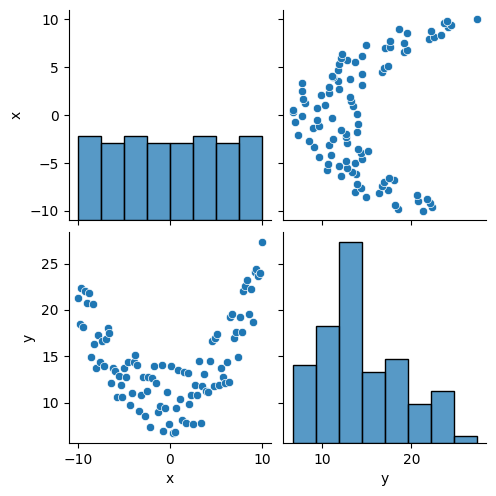

In [8]:
sns.pairplot(df)

We can see that `y` is quadratically dependent upon `x`.

<Axes: >

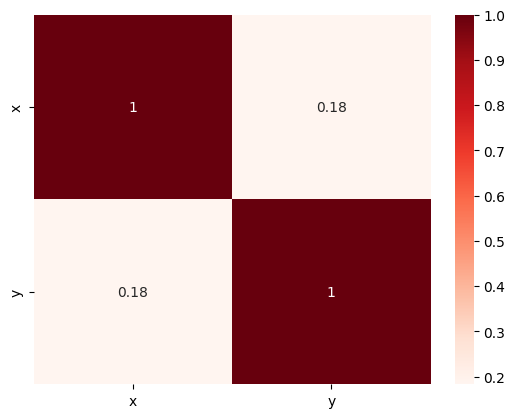

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='Reds')

## Dataset preparation and Model Training

1. Split the dataset into two separate datasets :
    - input data
    - output data
2. Scale the datasets to ensure equal domination of each feature in the training (not necessary for dataset with only one feature)

In [10]:
from sklearn.preprocessing import MinMaxScaler

X = pd.DataFrame(df['x'])
y = pd.DataFrame(df['y'])

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y)

Split the datasets into : 
- training data (80% of the total data)
- test data (20% of the total data)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

## Linear Regression Model
Train the model

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)
lr.score(X_train, y_train)

0.05297405323406046

## Linear Regression Model

Predict the output for the test data and compare the predicted output with the actual value for the test input and calculate :
- Mean Square Error
- Mean Absolute Error
- R2 Score

MSE and MAE should be minimum, whereas R2 score should be maximum (more closer to 1, better results).

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"mae : {mae:.10f}")
print(f"mse : {mse:.10f}")
print(f"rmse : {rmse:.10f}")
print(f"r2 score : {r2:.10f}")


mae : 0.1702127783
mse : 0.0457338326
rmse : 0.2138546997
r2 score : -0.1029784854


**Inference :** 

The model performed with a poor r2 score of -0.1 

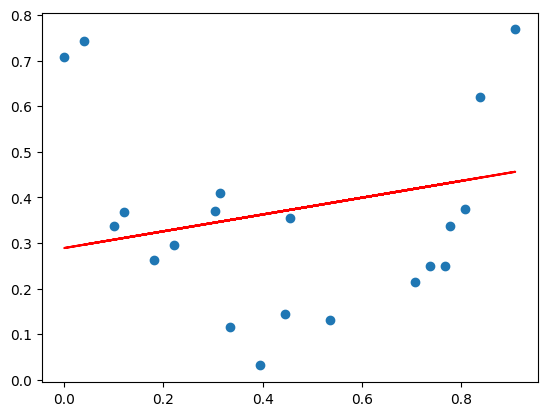

In [14]:
plt.plot(X_test, y_pred, color='r')
plt.scatter(X_test, y_test)
plt.show()

## Training an Artificial Neural Network

Now, the same dataset is trained under a two layer artifical neural network.

**Architecture** :
- The hidden layer contains four neurons, and 
- The output layer contains one neuron.

As the problem is based on linear regression, 
- `tanh` activation function is used for neurons in hidden layer, and
- `linear` activation function is used for the neuron on output layer.

In [73]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()
ann.add(Dense(4, activation='tanh', input_dim=1))
ann.add(Dense(1, activation='linear'))
ann.summary()

d:\Code n Develop\my-projects\regression-models\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate = 0.01)
ann.compile(optimizer=optimizer, loss='mse', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=250)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.0250 - loss: 0.0146
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0250 - loss: 0.0147
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0250 - loss: 0.0129
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0250 - loss: 0.0141
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0250 - loss: 0.0135
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0250 - loss: 0.0130
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0250 - loss: 0.0133
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0250 - loss: 0.0128    
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0250 - loss: 0.0138
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0250 - loss: 0.0134    
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0250 - loss: 0.0130     
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = ann.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"mae : {mae:.10f}")
print(f"mse : {mse:.10f}")
print(f"rmse : {rmse:.10f}")
print(f"r2 score : {r2:.10f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
mae : 0.1137598601
mse : 0.0157053515
rmse : 0.1253209937
r2 score : 0.6212286659


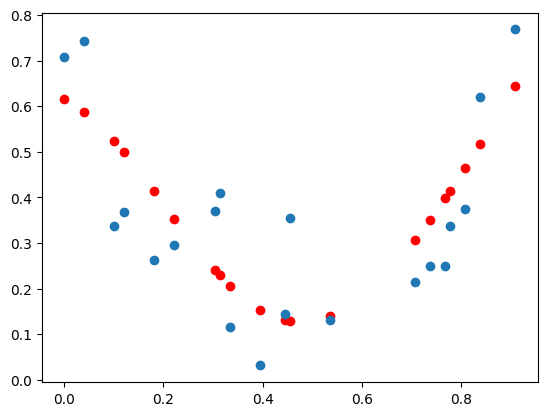

In [82]:
plt.scatter(X_test, y_pred, color='r')
plt.scatter(X_test, y_test)
plt.show()

**Inference:**

The Artificial Neural Network (ANN) model produced better results than the linear model, with an `r2 score` of 0.6. It was able to learn and capture the polynomial relationship between the input feature and the output label more effectively.

**Intermediate Training Observations:**

* The **ReLU** activation function in the hidden layer was unable to learn the polynomial behavior effectively because a large number of neuron outputs were negative. Since ReLU converts negative values to zero, some neurons became inactive, resulting in little or no weight updates during training.

* The **sigmoid** activation function experienced the **vanishing gradient problem**, causing the gradients to become very small. As a result, weight updates were minimal, leading to slow learning and reduced model performance.
